In [1]:
# Install and import necessary NLP and visualization libraries
!pip install nltk pandas scikit-learn matplotlib seaborn -q
import nltk
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Set plotting style
sns.set_theme(style="whitegrid")
print("Libraries, dependencies, and visualization tools loaded successfully!")

Libraries, dependencies, and visualization tools loaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [2]:
# Target Job Description
job_description = "Looking for a Data Scientist with strong experience in Python, Machine Learning, SQL, Pandas, Scikit-Learn, and Natural Language Processing. Experience with cloud platforms and deep learning is a plus."

# Sample resume dataset
resumes_data = {
    'Candidate_ID': ['C01', 'C02', 'C03', 'C04', 'C05'],
    'Candidate_Name': ['Alice Smith', 'Bob Jones', 'Charlie Brown', 'Diana Prince', 'Evan Wright'],
    'Resume_Text': [
        "Experienced Data Scientist skilled in Python, machine learning, SQL, pandas, scikit-learn, and natural language processing. Built NLP models for text classification and sentiment analysis.",
        "Software Engineer with 3 years of experience in Java, Spring Boot, MySQL, and REST APIs. Basic knowledge of python and git.",
        "Senior Data Analyst proficient in SQL, Tableau, Excel, Python, and statistical modeling. Experienced in data visualization and database management.",
        "Machine Learning Engineer with expertise in Python, deep learning, PyTorch, scikit-learn, NLP, and cloud deployment (AWS).",
        "Marketing Specialist with skills in digital marketing, SEO, Google Analytics, content writing, and social media management."
    ]
}

df_resumes = pd.DataFrame(resumes_data)
df_resumes.head()

,Candidate_ID,Candidate_Name,Resume_Text
0,C01,Alice Smith,"Experienced Data Scientist skilled in Python, ..."
1,C02,Bob Jones,Software Engineer with 3 years of experience i...
2,C03,Charlie Brown,"Senior Data Analyst proficient in SQL, Tableau..."
3,C04,Diana Prince,Machine Learning Engineer with expertise in Py...
4,C05,Evan Wright,Marketing Specialist with skills in digital ma...


In [3]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase text
    text = text.lower()
    # 2. Remove HTML tags and URLs
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 3. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenization, Stopword Removal, & Lemmatization
    tokens = text.split()
    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 1
    ]

    return " ".join(cleaned_tokens)

# Apply preprocessing to resumes and job description
df_resumes['Cleaned_Resume'] = df_resumes['Resume_Text'].apply(preprocess_text)
cleaned_jd = preprocess_text(job_description)

df_resumes[['Candidate_ID', 'Candidate_Name', 'Cleaned_Resume']]

,Candidate_ID,Candidate_Name,Cleaned_Resume
0,C01,Alice Smith,experienced data scientist skilled python mach...
1,C02,Bob Jones,software engineer year experience java spring ...
2,C03,Charlie Brown,senior data analyst proficient sql tableau exc...
3,C04,Diana Prince,machine learning engineer expertise python dee...
4,C05,Evan Wright,marketing specialist skill digital marketing s...


In [4]:
# Predefined skill database for matching
skill_database = [
    'python', 'machine learning', 'sql', 'pandas', 'scikit-learn',
    'natural language processing', 'nlp', 'deep learning', 'pytorch',
    'aws', 'java', 'tableau', 'excel', 'seo', 'git', 'mysql'
]

def extract_skills(text):
    text_lower = text.lower()
    found_skills = [skill for skill in skill_database if skill in text_lower]
    return list(set(found_skills))

# Extract skills from each resume
df_resumes['Extracted_Skills'] = df_resumes['Resume_Text'].apply(extract_skills)
df_resumes[['Candidate_ID', 'Candidate_Name', 'Extracted_Skills']]

,Candidate_ID,Candidate_Name,Extracted_Skills
0,C01,Alice Smith,"[nlp, pandas, scikit-learn, machine learning, ..."
1,C02,Bob Jones,"[git, sql, python, mysql, java]"
2,C03,Charlie Brown,"[tableau, excel, sql, python]"
3,C04,Diana Prince,"[nlp, pytorch, deep learning, aws, scikit-lear..."
4,C05,Evan Wright,"[seo, git]"


In [5]:
# Combine Job Description and Resumes into a single corpus for TF-IDF
corpus = [cleaned_jd] + df_resumes['Cleaned_Resume'].tolist()

# Compute TF-IDF matrix
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)

# Calculate Cosine Similarity between Job Description (index 0) and all Resumes (indices 1 to N)
jd_vector = tfidf_matrix[0:1]
resume_vectors = tfidf_matrix[1:]

similarity_scores = cosine_similarity(resume_vectors, jd_vector).flatten()
df_resumes['Match_Score'] = similarity_scores * 100  # Convert to percentage

# Display ranked resumes
df_resumes[['Candidate_ID', 'Candidate_Name', 'Match_Score']].sort_values(by='Match_Score', ascending=False)

,Candidate_ID,Candidate_Name,Match_Score
0,C01,Alice Smith,43.570918
3,C04,Diana Prince,36.330592
2,C03,Charlie Brown,11.979337
1,C02,Bob Jones,11.500520
4,C05,Evan Wright,0.000000


/tmp/ipykernel_1729/4138066320.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_df, x='Match_Score', y='Candidate_Name', palette='mako')


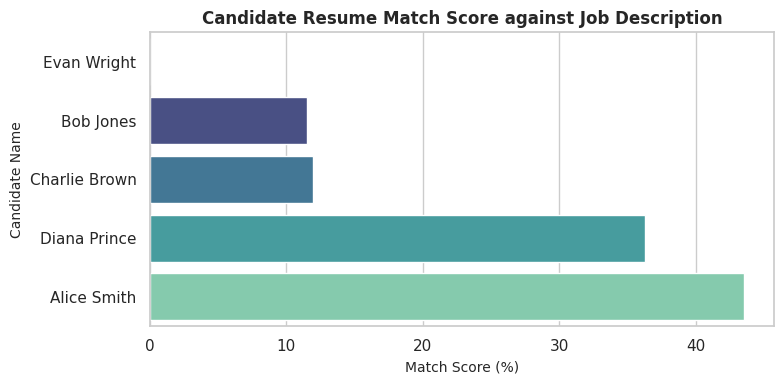

In [6]:
# Visualize candidate similarity matching scores
plt.figure(figsize=(8, 4))
sorted_df = df_resumes.sort_values(by='Match_Score', ascending=True)
sns.barplot(data=sorted_df, x='Match_Score', y='Candidate_Name', palette='mako')
plt.title('Candidate Resume Match Score against Job Description', fontsize=12, fontweight='bold')
plt.xlabel('Match Score (%)', fontsize=10)
plt.ylabel('Candidate Name', fontsize=10)
plt.tight_layout()
plt.show()

In [7]:
# Filter candidates based on a minimum match threshold (e.g., >= 15%)
shortlist_threshold = 15.0
shortlisted_df = df_resumes[df_resumes['Match_Score'] >= shortlist_threshold].sort_values(by='Match_Score', ascending=False)

print("=== HR Candidate Shortlist Report ===")
print(f"Target Job Role: Data Scientist")
print(f"Total Applicants Processed: {len(df_resumes)}")
print(f"Shortlisted Candidates: {len(shortlisted_df)}\n")

shortlisted_df[['Candidate_ID', 'Candidate_Name', 'Match_Score', 'Extracted_Skills']]

=== HR Candidate Shortlist Report ===
Target Job Role: Data Scientist
Total Applicants Processed: 5
Shortlisted Candidates: 2



,Candidate_ID,Candidate_Name,Match_Score,Extracted_Skills
0,C01,Alice Smith,43.570918,"[nlp, pandas, scikit-learn, machine learning, ..."
3,C04,Diana Prince,36.330592,"[nlp, pytorch, deep learning, aws, scikit-lear..."
